In [1]:
!pip install librosa soundfile numpy pandas matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import librosa

file_path = "../data/Audio_Speech_Actors_01-24/Actor_01/03-01-01-01-01-01-01.wav"

audio, sample_rate = librosa.load(file_path)

print(audio)
print(sample_rate)

[ 5.3765390e-08 -2.1233145e-08 -6.0478342e-09 ...  4.8083174e-14
 -9.6233243e-15  2.8714739e-14]
22050


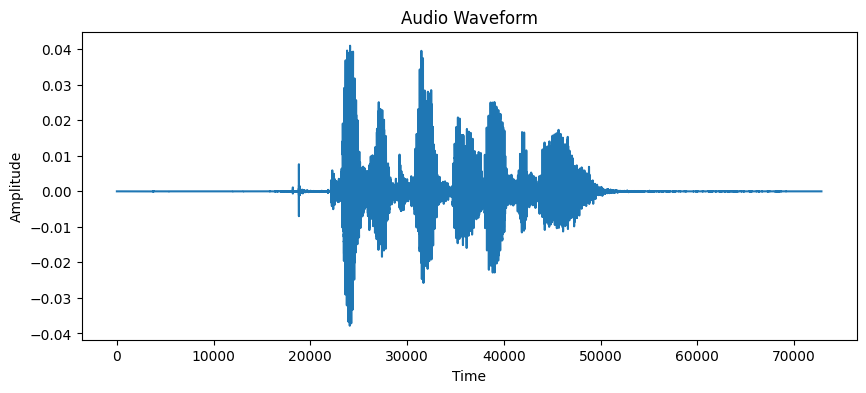

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.plot(audio)

plt.title("Audio Waveform")

plt.xlabel("Time")

plt.ylabel("Amplitude")

plt.show()

In [5]:
file_name = "03-01-05-01-01-01-01.wav"

emotion_code = file_name.split("-")[2]

print(emotion_code)

05


In [7]:
emotion_dict = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

emotion = emotion_dict[emotion_code]

print(emotion)

angry


In [9]:
import os

dataset_path = "../data/Audio_Speech_Actors_01-24"

emotion_list = []

for actor_folder in os.listdir(dataset_path):

    actor_path = os.path.join(dataset_path, actor_folder)

    for file in os.listdir(actor_path):

        emotion_code = file.split("-")[2]

        emotion = emotion_dict[emotion_code]

        emotion_list.append(emotion)

print(emotion_list[:10])

['neutral', 'neutral', 'neutral', 'neutral', 'calm', 'calm', 'calm', 'calm', 'calm', 'calm']


In [13]:
from collections import Counter

emotion_counts = Counter(emotion_list)

print(emotion_counts)

Counter({'calm': 192, 'happy': 192, 'sad': 192, 'angry': 192, 'fearful': 192, 'disgust': 192, 'surprised': 192, 'neutral': 96})


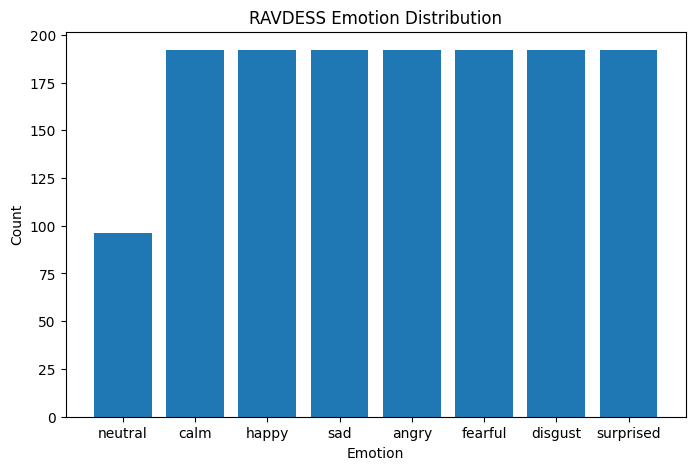

In [14]:
plt.figure(figsize=(8,5))

plt.bar(emotion_counts.keys(), emotion_counts.values())

plt.title("RAVDESS Emotion Distribution")

plt.xlabel("Emotion")

plt.ylabel("Count")

plt.show()

In [15]:
mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sample_rate,
    n_mfcc=40
)

print(mfcc.shape)

(40, 143)


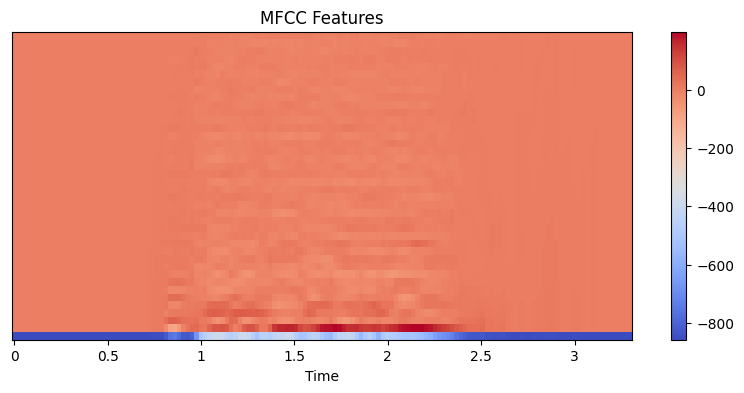

In [16]:
import librosa.display

plt.figure(figsize=(10,4))

librosa.display.specshow(
    mfcc,
    x_axis='time'
)

plt.colorbar()

plt.title('MFCC Features')

plt.show()